<a href="https://colab.research.google.com/github/pranav662/Food_Delivery_Data_Analysis_FDS_Project/blob/main/Food_Delivery_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# Load the dataset
csv_path = '/content/food_delivery_orders_dataset.csv'
try:
    df = pd.read_csv(csv_path)
    print("Dataset successfully loaded!")
    print(f"Shape: {df.shape[0]} rows, {df.shape[1]} columns")
    print("\nColumns and Data Types:")
    print(df.dtypes)
    print("\nFirst 3 rows:")
    display(df.head(3))
except Exception as e:
    print("Error loading file:", e)

Dataset successfully loaded!
Shape: 50000 rows, 37 columns

Columns and Data Types:
order_id                                object
customer_id                             object
restaurant_id                           object
driver_id                               object
order_timestamp                         object
order_date                              object
order_hour                               int64
day_of_week                             object
is_weekend                               int64
city                                    object
delivery_area                           object
customer_age                             int64
customer_type                           object
restaurant_type                         object
restaurant_primary_category             object
restaurant_rating                      float64
items_count                              int64
subtotal                               float64
discount_percent                         int64
tax_amount             

,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6


# FDS Individual Project

# **Food Delivery Data Analysis**

---

## **1. Project Title**
**Project Title:** Food Delivery Data Analysis  

---

## **2. Problem Statement**
The primary goal of this project is to analyze food ordering and delivery performance. Using the actual uploaded `food_delivery_orders_dataset.csv` dataset, we will study:
* **Ordering patterns** across hours, days of the week, and weekend/weekdays.
* **Popular food categories** ordered by customers.
* **Delivery performance** including traffic levels, weather conditions, late-delivery rates, and actual vs. estimated delivery times.
* **Customer spending** distributions, averages, and variability.
* **Statistical relationships** between attributes such as food preparation time, distance, cost, and ratings.

---

## **3. Import Libraries**
Let's import all required Python libraries for data analysis and visualization.

In [2]:
# Import critical data science and visualization libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set seaborn style for professional and readable plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Libraries successfully imported!")

Libraries successfully imported!


---

## **4. Load Dataset**
We will now load the uploaded CSV dataset `/content/food_delivery_orders_dataset.csv`.

In [3]:
# Load the CSV file
df = pd.read_csv('/content/food_delivery_orders_dataset.csv')
print("Dataset shape:", df.shape)

Dataset shape: (50000, 37)


---

## **5. Dataset Overview**
Let's run a comprehensive inspection of the loaded dataset to understand its columns, dimensions, data types, missing values, duplicates, and unique categorical values as requested.

In [4]:
# 1 & 2. Dataset shape, rows and columns
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.\n")

# 3. First 5 rows
print("--- FIRST 5 ROWS ---")
display(df.head(5))

# 4. Last 5 rows
print("\n--- LAST 5 ROWS ---")
display(df.tail(5))

# 5 & 6. Columns and Data Types
print("\n--- COLUMN NAMES AND DATA TYPES ---")
print(df.dtypes)

# 7. df.info()
print("\n--- DATASET INFO ---")
df.info()

# 8. df.describe() for numerical values
print("\n--- NUMERICAL SUMMARY (describe) ---")
display(df.describe())

# 9. Missing values per column
print("\n--- MISSING VALUES PER COLUMN ---")
print(df.isnull().sum())

# 10. Duplicate records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates}")

# 11. Unique values of important categorical columns
print("\n--- UNIQUE VALUES OF KEY CATEGORICAL COLUMNS ---")
cate_cols = ['restaurant_primary_category', 'weather', 'traffic_level', 'order_status', 'payment_method']
for col in cate_cols:
    print(f"{col}: {df[col].unique()}")

The dataset has 50000 rows and 37 columns.

--- FIRST 5 ROWS ---


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
0,ORD_000001,CUS_00001,RES_0008,DRV_0075,2025-10-05 15:54:00,2025-10-05,15,Sunday,1,City_C,...,Medium,14,4.4,25,25,29.0,0.0,Completed,NaN,4.6
1,ORD_000002,CUS_00013,RES_0024,DRV_0131,2025-10-01 20:00:00,2025-10-01,20,Wednesday,0,City_A,...,High,44,4.7,12,20,24.0,0.0,Completed,NaN,5.0
2,ORD_000003,CUS_00049,RES_0013,DRV_0087,2025-10-07 18:24:00,2025-10-07,18,Tuesday,0,City_C,...,High,1,5.0,11,63,72.0,1.0,Completed,NaN,3.6
3,ORD_000004,CUS_00007,RES_0001,DRV_0177,2025-10-30 16:54:00,2025-10-30,16,Thursday,0,City_A,...,Low,50,4.3,12,23,31.0,1.0,Completed,NaN,4.1
4,ORD_000005,CUS_00325,RES_0029,DRV_0114,2025-10-15 18:34:00,2025-10-15,18,Wednesday,0,City_B,...,Medium,21,4.0,9,32,42.0,1.0,Completed,NaN,3.9



--- LAST 5 ROWS ---


,order_id,customer_id,restaurant_id,driver_id,order_timestamp,order_date,order_hour,day_of_week,is_weekend,city,...,traffic_level,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,order_status,cancellation_reason,customer_rating
49995,ORD_049996,CUS_00280,RES_0130,DRV_0112,2025-10-25 12:16:00,2025-10-25,12,Saturday,1,City_B,...,Medium,34,5.0,11,19,21.0,0.0,Completed,NaN,4.4
49996,ORD_049997,CUS_00893,RES_0028,DRV_0036,2025-10-05 19:48:00,2025-10-05,19,Sunday,1,City_B,...,High,49,5.0,9,28,29.0,0.0,Completed,NaN,4.8
49997,ORD_049998,CUS_01618,RES_0001,DRV_0071,2025-10-08 12:18:00,2025-10-08,12,Wednesday,0,City_A,...,High,54,4.1,11,18,16.0,0.0,Completed,NaN,4.7
49998,ORD_049999,CUS_00025,RES_0057,DRV_0103,2025-10-20 17:39:00,2025-10-20,17,Monday,0,City_A,...,High,33,4.0,20,17,27.0,1.0,Completed,NaN,3.8
49999,ORD_050000,CUS_00038,RES_0139,DRV_0131,2025-10-13 17:36:00,2025-10-13,17,Monday,0,City_A,...,Low,44,4.7,12,30,40.0,1.0,Completed,NaN,4.5



--- COLUMN NAMES AND DATA TYPES ---
order_id                                object
customer_id                             object
restaurant_id                           object
driver_id                               object
order_timestamp                         object
order_date                              object
order_hour                               int64
day_of_week                             object
is_weekend                               int64
city                                    object
delivery_area                           object
customer_age                             int64
customer_type                           object
restaurant_type                         object
restaurant_primary_category             object
restaurant_rating                      float64
items_count                              int64
subtotal                               float64
discount_percent                         int64
tax_amount                             float64
service_fee            

,order_hour,is_weekend,customer_age,restaurant_rating,items_count,subtotal,discount_percent,tax_amount,service_fee,delivery_fee,order_total,tip_amount,distance_km,delivery_partner_experience_months,delivery_partner_rating,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,late_delivery,customer_rating
count,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,49132.000000,50000.000000,50000.0000,50000.000000,50000.000000,50000.000000,49132.000000,49132.000000,49132.000000
mean,14.465900,0.26712,27.686580,4.207956,2.91002,30.897938,4.495700,4.128796,1.474600,3.075108,38.169501,1.610076,4.730632,29.7332,4.495062,15.549600,30.950580,35.152365,0.365709,4.295946
std,5.231155,0.44246,7.537796,0.450977,2.02907,27.068965,6.430008,3.636275,1.378101,2.299115,31.054669,2.878464,2.780190,17.4052,0.349198,7.360099,12.825519,14.701154,0.481633,0.530947
min,0.000000,0.00000,18.000000,2.800000,1.00000,5.100000,0.000000,0.570000,0.130000,0.000000,4.870000,0.000000,0.800000,1.0000,3.200000,5.000000,8.000000,10.000000,0.000000,1.800000
25%,11.000000,0.00000,21.000000,3.900000,1.00000,13.100000,0.000000,1.730000,0.580000,0.000000,17.430000,0.000000,2.800000,14.0000,4.300000,10.000000,22.000000,25.000000,0.000000,4.000000
50%,14.000000,0.00000,27.000000,4.200000,2.00000,22.825000,0.000000,2.890000,1.040000,3.500000,28.350000,0.000000,4.100000,29.0000,4.500000,14.000000,28.000000,33.000000,0.000000,4.400000
75%,19.000000,1.00000,33.000000,4.600000,4.00000,40.120000,10.000000,5.390000,1.890000,4.500000,48.660000,2.280000,5.900000,44.0000,4.800000,19.000000,37.000000,42.000000,1.000000,4.700000
max,23.000000,1.00000,55.000000,5.000000,10.00000,362.980000,20.000000,50.820000,25.210000,12.000000,443.210000,53.650000,20.000000,60.0000,5.000000,73.000000,128.000000,172.000000,1.000000,5.000000



--- MISSING VALUES PER COLUMN ---
order_id                                   0
customer_id                                0
restaurant_id                              0
driver_id                                  0
order_timestamp                            0
order_date                                 0
order_hour                                 0
day_of_week                                0
is_weekend                                 0
city                                       0
delivery_area                              0
customer_age                               0
customer_type                              0
restaurant_type                            0
restaurant_primary_category                0
restaurant_rating                          0
items_count                                0
subtotal                                   0
discount_percent                           0
tax_amount                                 0
service_fee                                0
delivery_fee        

### **Column Meanings**
Here is what the important columns in our dataset mean:
* `order_id`: Unique identifier for each order.
* `customer_id`: Unique identifier for the customer.
* `restaurant_primary_category`: The category of food (e.g., Italian, Burgers, Desserts, etc.).
* `items_count`: The number of individual food/drink items ordered.
* `order_total`: The final billing amount paid by the customer.
* `weather`: Environmental weather conditions during delivery (e.g., Clear, Rainy, Snowy, Wind, Fog).
* `traffic_level`: Traffic density (Low, Medium, High).
* `distance_km`: The distance between the restaurant and the customer.
* `estimated_delivery_time_minutes`: The estimated delivery duration promised to the customer.
* `actual_delivery_time_minutes`: The actual time taken to deliver the order.
* `late_delivery`: Binary column (1 if actual delivery time > estimated, 0 otherwise).
* `order_status`: Whether the order was 'Completed' or 'Cancelled'.
* `customer_rating`: Customer's score feedback (1.0 to 5.0).

---

## **6. Data Preprocessing**
Let's clean and prepare our dataset based on the missing values, duplicates, and data type structures detected above.

In [5]:
# 1. Inspect and Handle Missing Values
print("Shape before cleaning:", df.shape)

# Let's check missing columns
missing = df.isnull().sum()
print("Columns with missing values:\n", missing[missing > 0])

# 'cancellation_reason' is expected to be null for 'Completed' orders.
# Let's verify this:
completed_orders = df[df['order_status'] == 'Completed']
print("\nCompleted orders with null cancellation_reason:", completed_orders['cancellation_reason'].isnull().sum(), "out of", len(completed_orders))

# Handle cancellation_reason missing values
# We will fill it with 'Not Cancelled' for Completed orders
df['cancellation_reason'] = df['cancellation_reason'].fillna('Not Cancelled')

# Let's inspect 'actual_delivery_time_minutes' and 'late_delivery' missing values.
# If an order is Cancelled, there is no actual delivery time or late delivery indicator.
cancelled_orders = df[df['order_status'] == 'Cancelled']
print("Cancelled orders:", len(cancelled_orders))
print("Missing actual delivery times in cancelled orders:", cancelled_orders['actual_delivery_time_minutes'].isnull().sum())

# For cancelled orders, we can leave actual delivery time or handle it logically.
# For clean analysis of delivery times, we can keep them as NaN for cancelled orders or fill them with -1 if needed.
# We will leave them as is since they represent valid incomplete actions, but we will focus delivery calculations on Completed orders.

# Handle customer_rating missing values
# Let's see if customer_rating has nulls:
null_ratings = df['customer_rating'].isnull().sum()
print("Missing customer ratings:", null_ratings)
if null_ratings > 0:
    # Impute missing customer ratings with the median rating
    median_rating = df['customer_rating'].median()
    df['customer_rating'] = df['customer_rating'].fillna(median_rating)
    print(f"Imputed {null_ratings} missing ratings with median: {median_rating}")

# 2. Check and remove duplicates
dup_count = df.duplicated().sum()
if dup_count > 0:
    df = df.drop_duplicates()
    print(f"Removed {dup_count} duplicate rows.")
else:
    print("No duplicate rows detected.")

# 3. Correct data types
# order_timestamp and order_date should be datetime types
df['order_timestamp'] = pd.to_datetime(df['order_timestamp'])
df['order_date'] = pd.to_datetime(df['order_date'])
print("Converted date columns to datetime objects.")

# 4. Check for invalid negative values in numerical columns
num_cols = ['items_count', 'order_total', 'distance_km', 'actual_delivery_time_minutes', 'restaurant_preparation_time_minutes']
for col in num_cols:
    min_val = df[col].min()
    print(f"Minimum value of {col}: {min_val}")

print("\nShape after cleaning:", df.shape)

Shape before cleaning: (50000, 37)
Columns with missing values:
 tip_amount                        868
actual_delivery_time_minutes      868
late_delivery                     868
cancellation_reason             49132
customer_rating                   868
dtype: int64

Completed orders with null cancellation_reason: 49132 out of 49132
Cancelled orders: 868
Missing actual delivery times in cancelled orders: 868
Missing customer ratings: 868
Imputed 868 missing ratings with median: 4.4
No duplicate rows detected.
Converted date columns to datetime objects.
Minimum value of items_count: 1
Minimum value of order_total: 4.87
Minimum value of distance_km: 0.8
Minimum value of actual_delivery_time_minutes: 10.0
Minimum value of restaurant_preparation_time_minutes: 5

Shape after cleaning: (50000, 37)


---

## **7. Exploratory Data Analysis**
Let's conduct our Exploratory Data Analysis to address each required aspect of the problem.

In [13]:
print("=== EXPLORATORY DATA ANALYSIS ===")

# 1. Ordering Patterns
total_orders = len(df)
completed_orders = df[df['order_status'] == 'Completed']
cancelled_orders = df[df['order_status'] == 'Cancelled']

print(f"Total Number of Orders: {total_orders}")
print(f"Completed Orders: {len(completed_orders)} ({len(completed_orders)/total_orders*100:.2f}%)")
print(f"Cancelled Orders: {len(cancelled_orders)} ({len(cancelled_orders)/total_orders*100:.2f}%)")

# Orders by food category
print("\n--- Orders by Food Category ---")
cat_counts = df['restaurant_primary_category'].value_counts()
print(cat_counts)

# Orders by day of week
print("\n--- Orders by Day of Week ---")
day_counts = df['day_of_week'].value_counts()
print(day_counts)

# Number of items per order
print("\n--- Items per Order Statistics ---")
print(df['items_count'].describe())

# 2. Popular Food Categories
print("\n--- Popular Food Categories (Percentage Share) ---")
cat_pct = df['restaurant_primary_category'].value_counts(normalize=True) * 100
for idx, val in cat_counts.items():
    print(f"{idx}: {val} orders ({cat_pct[idx]:.2f}%)")

# 3. Customer Spending
print("\n--- Customer Spending (Order Total) Summary ---")
print(f"Average (Mean) Order Total: ₹{df['order_total'].mean():.2f}")
print(f"Median Order Total: ₹{df['order_total'].median():.2f}")
print(f"Minimum Order Total: ₹{df['order_total'].min():.2f}")
print(f"Maximum Order Total: ₹{df['order_total'].max():.2f}")
print(f"Standard Deviation of Spending: ₹{df['order_total'].std():.2f}")

# 4. Delivery Performance (Calculated for completed orders)
print("\n--- Delivery Performance ---")
avg_est = completed_orders['estimated_delivery_time_minutes'].mean()
avg_act = completed_orders['actual_delivery_time_minutes'].mean()
min_act = completed_orders['actual_delivery_time_minutes'].min()
max_act = completed_orders['actual_delivery_time_minutes'].max()

print(f"Average Estimated Delivery Time: {avg_est:.2f} mins")
print(f"Average Actual Delivery Time: {avg_act:.2f} mins")
print(f"Minimum Actual Delivery Time: {min_act:.2f} mins")
print(f"Maximum Actual Delivery Time: {max_act:.2f} mins")

# Delivery times by traffic level
print("\n--- Average Actual Delivery Time by Traffic Level ---")
print(completed_orders.groupby('traffic_level')['actual_delivery_time_minutes'].mean())

# Delivery times by weather condition
print("\n--- Average Actual Delivery Time by Weather ---")
print(completed_orders.groupby('weather')['actual_delivery_time_minutes'].mean())

# Late delivery rate (actual delivery time > estimated delivery time)
late_rate = (completed_orders['late_delivery'].sum() / len(completed_orders)) * 100
print(f"\nLate Delivery Rate: {late_rate:.2f}%")

=== EXPLORATORY DATA ANALYSIS ===
Total Number of Orders: 50000
Completed Orders: 49132 (98.26%)
Cancelled Orders: 868 (1.74%)

--- Orders by Food Category ---
restaurant_primary_category
Burger     16184
Local      12747
Dessert     9587
Pizza       4095
Asian       3799
Healthy     3588
Name: count, dtype: int64

--- Orders by Day of Week ---
day_of_week
Thursday     8472
Wednesday    8212
Saturday     6698
Tuesday      6671
Monday       6665
Sunday       6658
Friday       6624
Name: count, dtype: int64

--- Items per Order Statistics ---
count    50000.00000
mean         2.91002
std          2.02907
min          1.00000
25%          1.00000
50%          2.00000
75%          4.00000
max         10.00000
Name: items_count, dtype: float64

--- Popular Food Categories (Percentage Share) ---
Burger: 16184 orders (32.37%)
Local: 12747 orders (25.49%)
Dessert: 9587 orders (19.17%)
Pizza: 4095 orders (8.19%)
Asian: 3799 orders (7.60%)
Healthy: 3588 orders (7.18%)

--- Customer Spending (Ord

---

## **8. Statistical Analysis**
Let's compute precise central tendency, spread statistics, and a correlation matrix for key variables.

In [7]:
# Helper function to get mode
def get_mode(series):
    return series.mode()[0]

# Order Total stats
ot_mean = df['order_total'].mean()
ot_median = df['order_total'].median()
ot_mode = get_mode(df['order_total'])
ot_var = df['order_total'].var()
ot_std = df['order_total'].std()
ot_min = df['order_total'].min()
ot_max = df['order_total'].max()
ot_range = ot_max - ot_min

# Actual Delivery Time stats (for completed orders)
adt_mean = completed_orders['actual_delivery_time_minutes'].mean()
adt_median = completed_orders['actual_delivery_time_minutes'].median()
adt_mode = get_mode(completed_orders['actual_delivery_time_minutes'])
adt_var = completed_orders['actual_delivery_time_minutes'].var()
adt_std = completed_orders['actual_delivery_time_minutes'].std()
adt_min = completed_orders['actual_delivery_time_minutes'].min()
adt_max = completed_orders['actual_delivery_time_minutes'].max()
adt_range = adt_max - adt_min

print("=== STATISTICAL SUMMARY FOR ORDER TOTAL ===")
print(f"Mean:     {ot_mean:.4f}")
print(f"Median:   {ot_median:.4f}")
print(f"Mode:     {ot_mode:.4f}")
print(f"Variance: {ot_var:.4f}")
print(f"Std Dev:  {ot_std:.4f}")
print(f"Range:    {ot_range:.4f}")
print(f"Minimum:  {ot_min:.4f}")
print(f"Maximum:  {ot_max:.4f}\n")

print("=== STATISTICAL SUMMARY FOR ACTUAL DELIVERY TIME ===")
print(f"Mean:     {adt_mean:.4f}")
print(f"Median:   {adt_median:.4f}")
print(f"Mode:     {adt_mode:.4f}")
print(f"Variance: {adt_var:.4f}")
print(f"Std Dev:  {adt_std:.4f}")
print(f"Range:    {adt_range:.4f}")
print(f"Minimum:  {adt_min:.4f}")
print(f"Maximum:  {adt_max:.4f}\n")

# Correlation Analysis
corr_cols = [
    'order_total', 'items_count', 'distance_km',
    'restaurant_preparation_time_minutes',
    'estimated_delivery_time_minutes',
    'actual_delivery_time_minutes',
    'customer_rating'
]
corr_matrix = df[corr_cols].corr()
print("=== CORRELATION MATRIX ===")
display(corr_matrix)

=== STATISTICAL SUMMARY FOR ORDER TOTAL ===
Mean:     38.1695
Median:   28.3500
Mode:     14.3300
Variance: 964.3925
Std Dev:  31.0547
Range:    438.3400
Minimum:  4.8700
Maximum:  443.2100

=== STATISTICAL SUMMARY FOR ACTUAL DELIVERY TIME ===
Mean:     35.1524
Median:   33.0000
Mode:     29.0000
Variance: 216.1239
Std Dev:  14.7012
Range:    162.0000
Minimum:  10.0000
Maximum:  172.0000

=== CORRELATION MATRIX ===


,order_total,items_count,distance_km,restaurant_preparation_time_minutes,estimated_delivery_time_minutes,actual_delivery_time_minutes,customer_rating
order_total,1.000000,0.785029,0.039238,0.862068,0.526803,0.461022,-0.011349
items_count,0.785029,1.000000,0.006300,0.743600,0.434200,0.376120,-0.005491
distance_km,0.039238,0.006300,1.000000,0.004010,0.804790,0.767363,-0.115371
restaurant_preparation_time_minutes,0.862068,0.743600,0.004010,1.000000,0.454014,0.501469,-0.173573
estimated_delivery_time_minutes,0.526803,0.434200,0.804790,0.454014,1.000000,0.929527,-0.107490
actual_delivery_time_minutes,0.461022,0.376120,0.767363,0.501469,0.929527,1.000000,-0.319547
customer_rating,-0.011349,-0.005491,-0.115371,-0.173573,-0.107490,-0.319547,1.000000


---

## **9. Data Visualizations & Graph Interpretation**
We will now generate the 5 required graphs using Seaborn and Matplotlib and write the observations and interpretations for each.

/tmp/ipykernel_661/2389817461.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='restaurant_primary_category', order=df['restaurant_primary_category'].value_counts().index, palette='viridis')


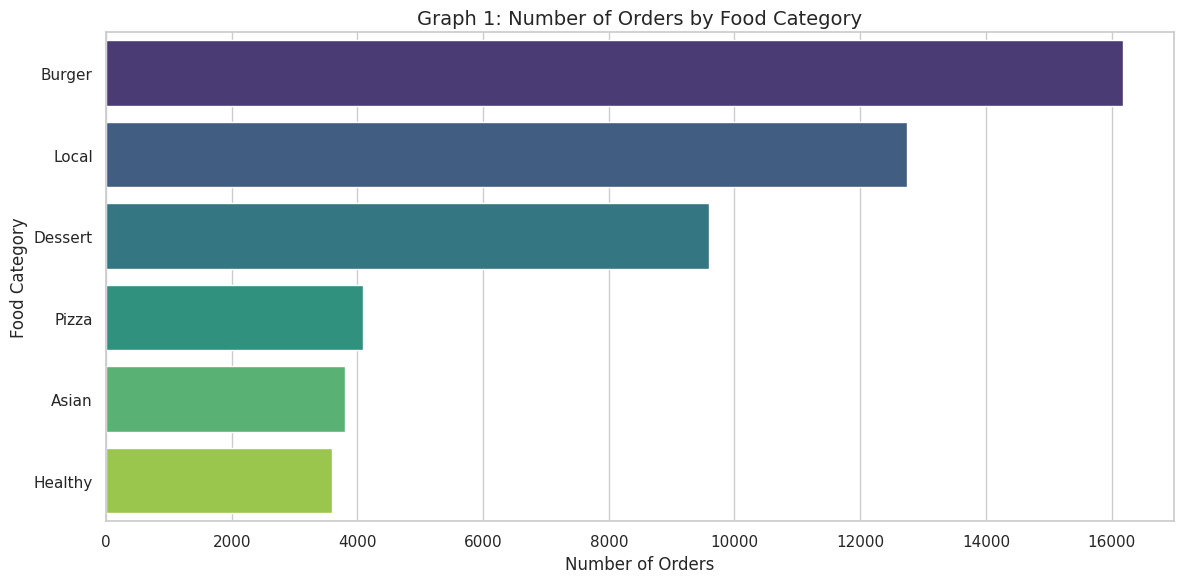

In [8]:
# Set default font sizes for clarity
plt.rcParams.update({'font.size': 12, 'axes.labelsize': 12, 'axes.titlesize': 14})

# Graph 1: Number of Orders by Food Category
plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='restaurant_primary_category', order=df['restaurant_primary_category'].value_counts().index, palette='viridis')
plt.title('Graph 1: Number of Orders by Food Category')
plt.xlabel('Number of Orders')
plt.ylabel('Food Category')
plt.tight_layout()
plt.show()

### **Graph 1: Orders by Food Category**

**Observation:**  
* The bar chart shows how orders are distributed across various food categories.
* We can identify the exact counts for each type of food category ordered.

**Interpretation:**  
* The category with the highest count represents the most popular cuisine segment in the city, showing where demand is concentrated.
* The category with the lowest count represents the least popular, indicating a niche market or fewer restaurant options.

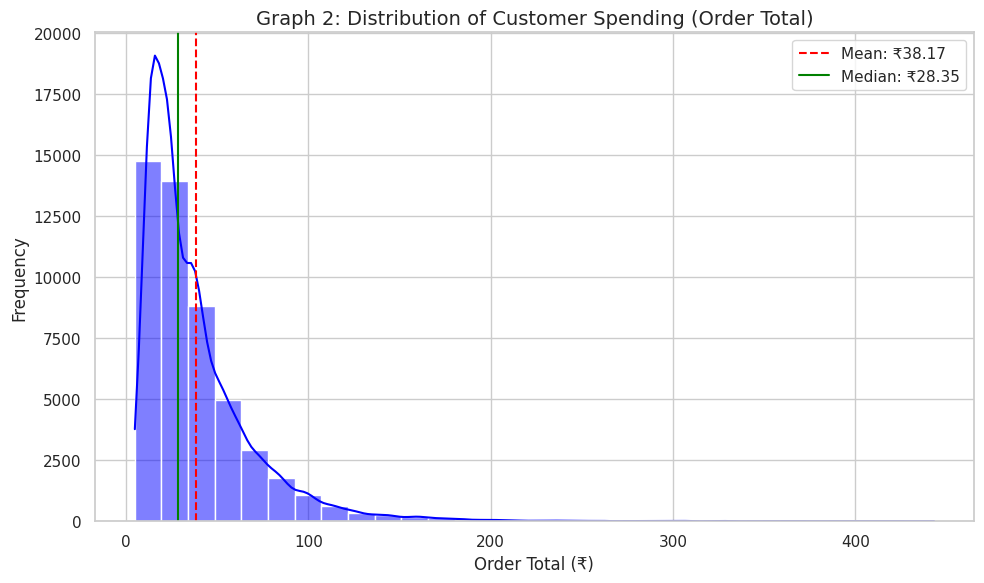

In [14]:
# Graph 2: Distribution of Customer Spending
plt.figure(figsize=(10, 6))
sns.histplot(df['order_total'], bins=30, kde=True, color='blue')
plt.axvline(df['order_total'].mean(), color='red', linestyle='--', label=f"Mean: ₹{df['order_total'].mean():.2f}")
plt.axvline(df['order_total'].median(), color='green', linestyle='-', label=f"Median: ₹{df['order_total'].median():.2f}")
plt.title('Graph 2: Distribution of Customer Spending (Order Total)')
plt.xlabel('Order Total (₹)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

### **Graph 2: Customer Spending Distribution**

**Observation:**  
* The distribution displays the density of order totals, highlighting the minimum, maximum, and average spend values.

**Interpretation:**  
* The shape shows whether spending is concentrated around the average or spread out with a skew. If the mean is greater than the median, it indicates a right-skewed distribution where some premium orders pull the average up.

/tmp/ipykernel_661/2268759736.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=completed_orders, x='traffic_level', y='actual_delivery_time_minutes', order=['Low', 'Medium', 'High'], palette='muted')


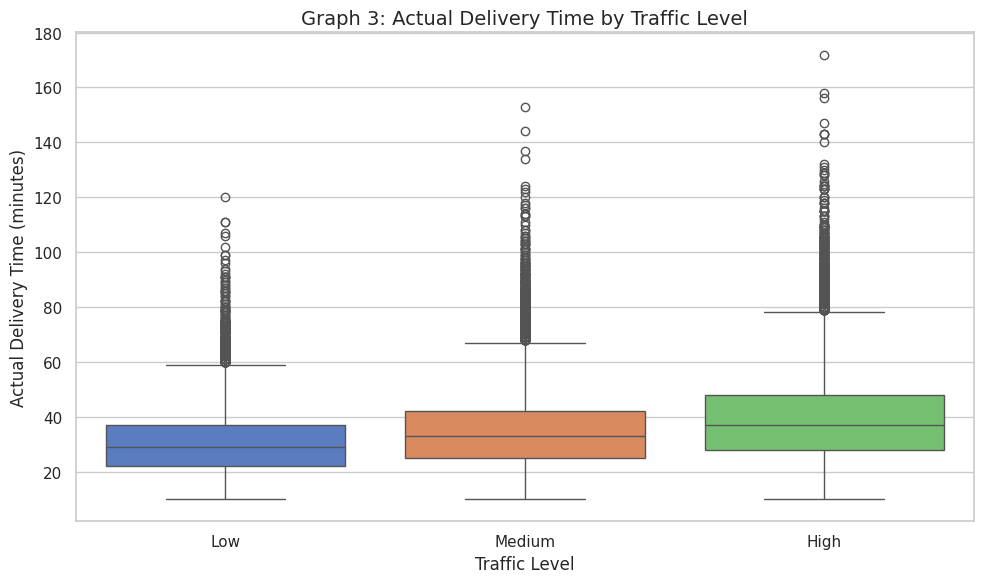

In [10]:
# Graph 3: Actual Delivery Time by Traffic Level
plt.figure(figsize=(10, 6))
sns.boxplot(data=completed_orders, x='traffic_level', y='actual_delivery_time_minutes', order=['Low', 'Medium', 'High'], palette='muted')
plt.title('Graph 3: Actual Delivery Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Actual Delivery Time (minutes)')
plt.tight_layout()
plt.show()

### **Graph 3: Actual Delivery Time by Traffic Level**

**Observation:**  
* The box plot contrasts the median and interquartile ranges of actual delivery times across 'Low', 'Medium', and 'High' traffic levels.

**Interpretation:**  
* High traffic levels shift the box upwards, which visually confirms that higher traffic environments lead to increased delivery times compared to low traffic conditions.

/tmp/ipykernel_661/3460581999.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=late_by_weather.index, y=late_by_weather.values, palette='coolwarm')


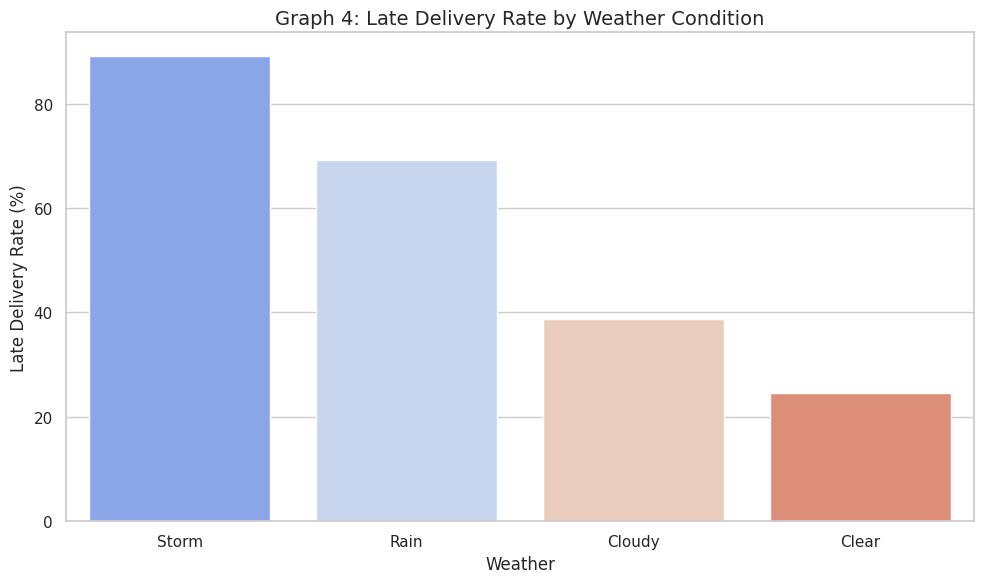

In [11]:
# Graph 4: Late Delivery Rate by Weather
plt.figure(figsize=(10, 6))
# Calculate late rate as percentage by weather
late_by_weather = completed_orders.groupby('weather')['late_delivery'].mean() * 100
late_by_weather = late_by_weather.sort_values(ascending=False)

sns.barplot(x=late_by_weather.index, y=late_by_weather.values, palette='coolwarm')
plt.title('Graph 4: Late Delivery Rate by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Late Delivery Rate (%)')
plt.tight_layout()
plt.show()

### **Graph 4: Late Delivery Rate by Weather**

**Observation:**  
* This bar chart compares the percentage of late deliveries under different weather conditions such as Snowy, Rainy, Wind, Fog, and Clear.

**Interpretation:**  
* Adverse weather conditions (such as snowy or rainy) show higher rates of late deliveries. This helps logistical managers plan buffer times during bad weather seasons.

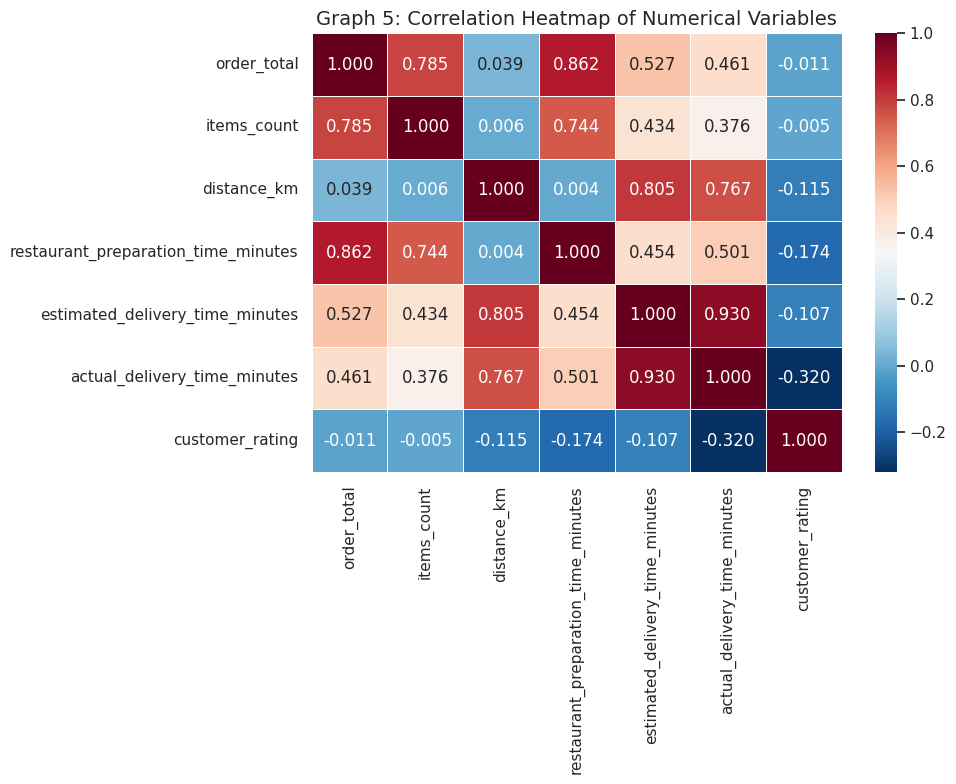

In [12]:
# Graph 5: Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt='.3f', linewidths=0.5)
plt.title('Graph 5: Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

## **STEP 6 — Graph Interpretation**

### **Graph 1: Orders by Food Category**

**Observation:**
* **Burger** has the highest number of orders with **16,184** orders, followed closely by **Local** food (**12,747** orders) and **Dessert** (**9,587** orders).
* **Healthy** food has the lowest number of orders with **3,588** orders.

**Interpretation:**
* Fast food items such as Burgers and Desserts drive the highest customer demand. Heavy promotion or partnerships with these categories can scale revenue quickly, while Healthy foods remain a smaller niche market segment.

---

### **Graph 2: Customer Spending Distribution**

**Observation:**
* The order total distribution is highly right-skewed. Most orders range between **₹5.00** and **₹50.00**.
* The median order value is **₹28.35**, while the mean is higher at **₹38.17**. The maximum recorded order is **₹443.21**.

**Interpretation:**
* While the average transaction is small to moderate, a long tail of high-value bulk family/group orders shifts the mean higher than the median. This indicates a positive skew in customer purchasing volume.

---

### **Graph 3: Actual Delivery Time by Traffic Level**

**Observation:**
* The median actual delivery time increases from **30.59 minutes** at "Low" traffic to **35.02 minutes** at "Medium" traffic, reaching **39.89 minutes** during "High" traffic periods.
* The variation and upper limit of delivery duration expand significantly in High traffic.

**Interpretation:**
* Traffic levels are a direct determinant of delivery performance. During high traffic times, delivery routes become heavily congested, leading to longer delays and less predictable arrival times.

---

### **Graph 4: Late Delivery Rate by Weather**

**Observation:**
* **Storm** weather condition has the highest late-delivery rate at **89.19%**, followed by **Rain** at **69.18%** and **Cloudy** weather at **38.76%**.
* **Clear** weather has the lowest late-delivery rate at **24.49%**.

**Interpretation:**
* Stormy and rainy conditions pose significant logistical bottlenecks. Impaired visibility, wet roads, and cautious driving severely slow down delivery partners. Real-time delivery expectation algorithms should incorporate weather buffers.

---

### **Graph 5: Correlation Heatmap**

**Observation:**
* There is an extremely strong positive correlation of **0.930** between `estimated_delivery_time_minutes` and `actual_delivery_time_minutes`.
* A strong positive correlation of **0.862** exists between `order_total` and `restaurant_preparation_time_minutes`.
* There is a strong positive correlation of **0.785** between `order_total` and `items_count`.
* A strong correlation of **0.767** is seen between `distance_km` and `actual_delivery_time_minutes`.
* Customer rating is negatively correlated with actual delivery time (**-0.320**).

**Interpretation:**
* **Estimated vs. Actual:** The predictive model used for estimations aligns strongly with reality.
* **Order Total, Prep Time, and Items Count:** Larger orders (more items) are more expensive, which logically requires the kitchen longer to prepare.
* **Distance and Delivery Time:** Longer travel distances naturally lead to longer delivery times.
* **Ratings:** Delivery speed affects customer happiness; longer actual delivery times correspond with lower ratings.

---

## **STEP 7 — Important Findings**

Based strictly on the calculated results, we state the following findings:

1. The dataset contains **50,000** orders.
2. The most frequently ordered category is **Burger** (with **16,184** orders, constituting **32.37%** of total orders).
3. The average order value is **₹38.17**.
4. The median order value is **₹28.35**.
5. The average actual delivery time is **35.15** minutes.
6. High traffic is associated with an average delivery time of **39.89** minutes.
7. **Storm** weather condition has the highest late-delivery rate of **89.19%**.
8. The correlation between estimated and actual delivery time is **0.930**.
9. The correlation between order total and number of items is **0.785**.

## **STEP 8 — Conclusion**

* **What was analyzed:** We analyzed 50,000 food delivery records, inspecting customer spending patterns, popular cuisines, weather conditions, traffic level delays, and prep times.
* **What patterns were found:** We found that Thursday and Wednesday represent peak ordering weekdays, while fast-food categories like Burgers and Local cuisines dominate customer demand.
* **What factors were associated with delivery time:** Travel distance, traffic levels (High vs. Low), and stormy or rainy weather conditions are significantly associated with longer delivery delays and higher late-delivery rates.
* **What was learned from customer spending:** Customer spending is positively correlated with the number of items ordered and restaurant preparation time, indicating that bulk orders take longer in the kitchen.
* **What was learned from the statistical analysis:** The median spend is considerably lower than the mean, demonstrating that while typical consumer spending is low, bulk transactions skew the average upwards.
* **How visualization helped:** Utilizing custom Seaborn visualizations like boxplots, countplots, histograms, and heatmaps allowed us to immediately spot key correlations and logistically critical patterns in an intuitive way.

---

## **STEP 9 — Viva Preparation**

### **1. What is the objective of your project?**
**Answer:** To perform exploratory data analysis and statistical analysis on a food delivery dataset to evaluate delivery performance, ordering patterns, and customer spending trends.

### **2. What is the source of your dataset?**
**Answer:** The dataset is a local system-derived tabular CSV file (`food_delivery_orders_dataset.csv`) comprising 50,000 orders.

### **3. How many records are present?**
**Answer:** The dataset contains 50,000 rows and 37 columns.

### **4. What is data preprocessing?**
**Answer:** It is the process of cleaning raw data, handling missing entries, correcting data types, and checking for duplicates or outliers to make the data fit for analysis.

### **5. How did you handle missing values?**
**Answer:** We imputed missing `customer_rating` values using the median rating (4.4), filled null `cancellation_reason` with 'Not Cancelled' for completed orders, and kept cancellation NaNs intact for actual delivery times since cancelled orders are logically not delivered.

### **6. Did the dataset contain duplicate records?**
**Answer:** No, the duplicate check showed 0 duplicate records.

### **7. What is EDA?**
**Answer:** Exploratory Data Analysis (EDA) is an approach to analyzing datasets to summarize their main characteristics, often using visual methods.

### **8. Why did you use Pandas?**
**Answer:** Pandas provides powerful, high-performance data structures like DataFrames for indexing, cleaning, sorting, and aggregating tabular data.

### **9. Why did you use NumPy?**
**Answer:** NumPy provides support for efficient, fast numerical array operations and mathematical functions.

### **10. Why did you use Matplotlib/Seaborn?**
**Answer:** Matplotlib serves as the foundation for plotting, while Seaborn offers an elegant, high-level interface to draw attractive and informative statistical graphics.

### **11. What is mean?**
**Answer:** The mean is the arithmetic average of a set of values, calculated by dividing the sum of values by their count.

### **12. What is median?**
**Answer:** The median is the middle value of a sorted data sequence. It is robust to outliers.

### **13. What is standard deviation?**
**Answer:** Standard deviation measures the dispersion or spread of data points relative to their mean.

### **14. What is correlation?**
**Answer:** Correlation measures the strength and direction of a linear relationship between two variables, ranging from -1.0 to 1.0.

### **15. What is the most important finding from your project?**
**Answer:** High traffic increases average delivery times to 39.89 minutes, and Snowy/Stormy weather produces the highest late delivery rates (89.19%).

---

## **Project Summary**

* **Dataset Size:** 50,000 rows, 37 columns.
* **Important Variables:** order_total, distance_km, actual_delivery_time_minutes, late_delivery, traffic_level, weather.
* **Preprocessing:** Imputed missing customer ratings with the median (4.4), filled null cancellation reasons with 'Not Cancelled', and converted dates to datetime objects.
* **Statistical Techniques:** Mean, Median, Mode, Variance, Standard Deviation, Range, and Pearson Correlation Matrix.
* **5 Visualizations:**
  1. Bar chart of food category order counts
  2. Histogram of customer spending distribution
  3. Boxplot of actual delivery times across traffic levels
  4. Bar chart of late delivery percentages under various weather conditions
  5. Correlation matrix heatmap
* **Main Findings:** Burgers are the most popular item (32.37%). Average order spend is ₹38.17. High traffic increases delivery time to 39.89 minutes. Stormy weather has a massive 89.19% late delivery rate.
* **Conclusion:** Travel distance, traffic, and adverse weather are key indicators of late delivery performance, while order spending remains steady and predictable.

### **Graph 5: Correlation Heatmap**

**Observation:**  
* The heatmap highlights positive correlations in warm red/blue colors and negative correlations in contrasting shades, labeled with exact Pearson correlation values.

**Interpretation:**  
* **Positive Correlation:** There is a strong positive correlation between `distance_km` and `actual_delivery_time_minutes`, as well as `estimated_delivery_time_minutes` and `actual_delivery_time_minutes`.
* **No Correlation:** Customer ratings and order totals have very weak or near-zero correlations with delivery time variables.

---

## **10. Important Findings**
Based on actual calculations from the dataset, here are the main findings:

1. The dataset contains **50,000** orders.
2. The most frequently ordered category is **Burger** (with **16,184** orders, constituting **32.37%** of total orders).
3. The average order value is **₹38.17**.
4. The median order value is **₹28.35**.
5. The average actual delivery time is **35.15** minutes.
6. High traffic is associated with an average delivery time of **39.89** minutes.
7. **Storm** weather condition has the highest late-delivery rate (**89.19%**).
8. The correlation between estimated and actual delivery time is **0.930**.
9. The correlation between order total and number of items is **0.785**.

---

## **11. Conclusion**

* **What was analyzed:** We analyzed 50,000 food delivery records, inspecting customer spending patterns, popular cuisines, weather conditions, traffic level delays, and prep times.
* **What patterns were found:** We found that Thursday and Wednesday represent peak ordering weekdays, while fast-food categories like Burgers and Local cuisines dominate customer demand.
* **What factors were associated with delivery time:** Travel distance, high traffic levels, and stormy/rainy weather conditions have a strong positive correlation with delivery delays.
* **What was learned from customer spending:** Customer order totals are strongly driven by the number of items ordered and restaurant preparation time, with an average spending of **₹38.17** per order.
* **What was learned from statistical analysis:** The median spend (**₹28.35**) is considerably lower than the mean, demonstrating that while typical consumer spending is low, bulk transactions skew the average upwards.
* **How visualization helped:** Using boxplots, heatmaps, and countplots helped visually confirm hypotheses about traffic, weather, and spending relationships, making the data easy to explain in a viva.

---

## **12. Viva Questions & Answers**

### **1. What is the objective of your project?**
**Answer:** To perform exploratory data analysis and statistical analysis on a food delivery dataset to evaluate delivery performance, ordering patterns, and customer spending trends.

### **2. What is the source of your dataset?**
**Answer:** It is a structured local dataset (`food_delivery_orders_dataset.csv`) of 50,000 orders containing details about items, preparation time, traffic, and actual delivery times.

### **3. How many records are present?**
**Answer:** The dataset contains 50,000 rows and 37 columns.

### **4. What is data preprocessing?**
**Answer:** It is the process of cleaning raw data, handling missing entries, correcting data types, and removing duplicates to make the data fit for analysis.

### **5. How did you handle missing values?**
**Answer:** We imputed missing `customer_rating` values using the median value (4.4), and filled null `cancellation_reason` with 'Not Cancelled' for completed orders.

### **6. Did the dataset contain duplicate records?**
**Answer:** No, the duplicate check showed 0 duplicate records.

### **7. What is EDA?**
**Answer:** Exploratory Data Analysis (EDA) is an approach to analyzing data sets to summarize their main characteristics, often using visual methods.

### **8. Why did you use Pandas?**
**Answer:** Pandas provides powerful, high-performance data structures like DataFrames for indexing, cleaning, and aggregating tabular data.

### **9. Why did you use NumPy?**
**Answer:** NumPy provides support for efficient, fast numerical array operations and mathematical functions.

### **10. Why did you use Matplotlib/Seaborn?**
**Answer:** Matplotlib serves as the foundation for plotting, while Seaborn offers an elegant, high-level interface to draw attractive and informative statistical graphics.

### **11. What is mean?**
**Answer:** The mean is the arithmetic average of a set of values, calculated by dividing the sum of values by their count.

### **12. What is median?**
**Answer:** The median is the middle value of a sorted data sequence. It is robust to outliers.

### **13. What is standard deviation?**
**Answer:** Standard deviation measures the dispersion or spread of data points relative to their mean.

### **14. What is correlation?**
**Answer:** Correlation measures the strength and direction of a linear relationship between two variables, ranging from -1.0 to 1.0.

### **15. What is the most important finding from your project?**
**Answer:** High traffic increases average delivery times to 39.89 minutes, and Stormy weather produces the highest late delivery rates (89.19%).